In [1]:
# %pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
training = pd.read_csv("../training_data.csv", encoding="latin1")
test = pd.read_csv("../test_data.csv", encoding="latin1")

In [3]:
# Dropping unique values

training.drop('city_name', axis=1, inplace=True)
test.drop('city_name', axis=1, inplace=True)

training.drop('AVERAGE_PRECIPITATION', axis=1, inplace=True)
test.drop('AVERAGE_PRECIPITATION', axis=1, inplace=True)

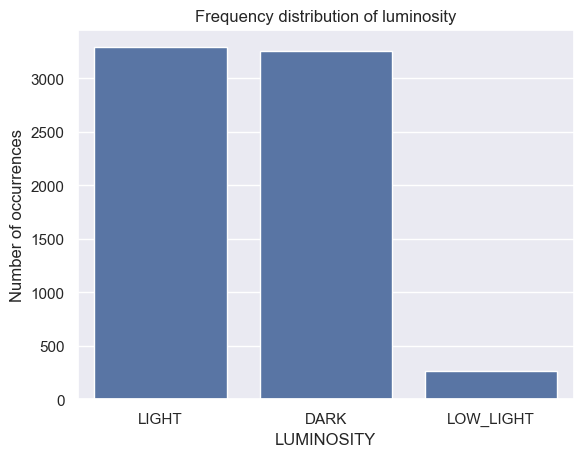

In [4]:
# Handling categorical data ... for LUMINOSITY

lum_count = training['LUMINOSITY'].value_counts()
sns.set(style='darkgrid')
sns.barplot(x=lum_count.index, y=lum_count.values)
plt.title('Frequency distribution of luminosity')
plt.ylabel('Number of occurrences', fontsize=12)
plt.xlabel('LUMINOSITY', fontsize=12)
plt.show()

In [5]:
# Using the factorising technique

training['LUMINOSITY'] = pd.factorize(training['LUMINOSITY'])[0]+1
test['LUMINOSITY'] = pd.factorize(test['LUMINOSITY'])[0]+1

In [6]:
cloudiness_training = pd.get_dummies(training['AVERAGE_CLOUDINESS'], drop_first=True)
cloudiness_test = pd.get_dummies(test['AVERAGE_CLOUDINESS'], drop_first=True)
rain_training = pd.get_dummies(training['AVERAGE_RAIN'], drop_first=True)
rain_test = pd.get_dummies(test['AVERAGE_RAIN'], drop_first=True)

training.drop(['AVERAGE_CLOUDINESS', 'AVERAGE_RAIN'], axis=1, inplace=True)
training = pd.concat([training,cloudiness_training, rain_training], axis=1)

test.drop(['AVERAGE_CLOUDINESS', 'AVERAGE_RAIN'], axis=1, inplace=True)
test = pd.concat([test,cloudiness_test, rain_test], axis=1)

In [7]:
training = training.dropna(subset=['record_date'])
training['record_date'] = pd.to_datetime(training['record_date'], format = '%Y-%m-%d %H:%M:%S', errors = 'coerce')
assert training['record_date'].isnull().sum() == 0, 'missing record date'
print(training['record_date'].head())

test = test.dropna(subset=['record_date'])
test['record_date'] = pd.to_datetime(test['record_date'], format = '%Y-%m-%d %H:%M:%S', errors = 'coerce')
assert test['record_date'].isnull().sum() == 0, 'missing record date'
print(test['record_date'].head())

0   2019-08-29 07:00:00
1   2018-08-10 14:00:00
2   2019-09-01 16:00:00
3   2019-02-26 11:00:00
4   2019-06-06 12:00:00
Name: record_date, dtype: datetime64[ns]
0   2019-02-13 23:00:00
1   2018-11-28 20:00:00
2   2018-08-14 05:00:00
3   2019-07-06 17:00:00
4   2018-10-15 06:00:00
Name: record_date, dtype: datetime64[ns]


In [8]:
training['record_date_year'] = training['record_date'].dt.year
training['record_date_month'] = training['record_date'].dt.month
training['record_date_day'] = training['record_date'].dt.day
training['record_date_hour'] = training['record_date'].dt.hour
training['record_date_minute'] = training['record_date'].dt.minute
training['record_date_second'] = training['record_date'].dt.second
training.head()

test['record_date_year'] = test['record_date'].dt.year
test['record_date_month'] = test['record_date'].dt.month
test['record_date_day'] = test['record_date'].dt.day
test['record_date_hour'] = test['record_date'].dt.hour
test['record_date_minute'] = test['record_date'].dt.minute
test['record_date_second'] = test['record_date'].dt.second
test.head()

,record_date,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,céu claro,...,chuva moderada,chuvisco fraco,trovoada com chuva,trovoada com chuva leve,record_date_year,record_date_month,record_date_day,record_date_hour,record_date_minute,record_date_second
0,2019-02-13 23:00:00,39.2,0.0,91.0,1,8.0,1026.0,71.0,1.0,True,...,False,False,False,False,2019,2,13,23,0,0
1,2018-11-28 20:00:00,42.5,12.2,76.8,1,11.0,1020.0,93.0,4.0,False,...,False,False,False,False,2018,11,28,20,0,0
2,2018-08-14 05:00:00,45.9,0.0,86.3,1,14.0,1017.0,93.0,0.0,False,...,False,False,False,False,2018,8,14,5,0,0
3,2019-07-06 17:00:00,33.2,51.7,89.9,2,22.0,1016.0,77.0,4.0,False,...,False,False,False,False,2019,7,6,17,0,0
4,2018-10-15 06:00:00,44.0,3.5,85.5,1,12.0,1004.0,100.0,9.0,False,...,False,False,False,False,2018,10,15,6,0,0


In [9]:
# Dropping unique date values

training.drop('record_date_minute', axis=1, inplace=True)
training.drop('record_date_second', axis=1, inplace=True)
training.drop('record_date', axis=1, inplace=True)
#training.dropna(inplace=True)
training.head()

test.drop('record_date_minute', axis=1, inplace=True)
test.drop('record_date_second', axis=1, inplace=True)
test.drop('record_date', axis=1, inplace=True)
test.dropna(inplace=True)
test.head()

,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,céu claro,céu limpo,...,chuva fraca,chuva leve,chuva moderada,chuvisco fraco,trovoada com chuva,trovoada com chuva leve,record_date_year,record_date_month,record_date_day,record_date_hour
0,39.2,0.0,91.0,1,8.0,1026.0,71.0,1.0,True,False,...,False,False,False,False,False,False,2019,2,13,23
1,42.5,12.2,76.8,1,11.0,1020.0,93.0,4.0,False,False,...,False,False,False,False,False,False,2018,11,28,20
2,45.9,0.0,86.3,1,14.0,1017.0,93.0,0.0,False,False,...,False,False,False,False,False,False,2018,8,14,5
3,33.2,51.7,89.9,2,22.0,1016.0,77.0,4.0,False,False,...,False,False,False,False,False,False,2019,7,6,17
4,44.0,3.5,85.5,1,12.0,1004.0,100.0,9.0,False,False,...,True,False,False,False,False,False,2018,10,15,6


In [10]:
# Preparar X_train e y_train
X_train_full = training.drop('AVERAGE_SPEED_DIFF', axis=1)
y_train_full = training['AVERAGE_SPEED_DIFF']

# X_test é o test completo (não tem AVERAGE_SPEED_DIFF)
X_test = test.copy()

print("Antes do alinhamento:")
print(f"X_train: {X_train_full.shape}")
print(f"X_test: {X_test.shape}")
print(f"X_train: {X_train_full.shape}")
print(f"X_test: {X_test.shape}")

# Adicionar colunas que existem no training mas não no test
missing_cols = set(X_train_full.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0
    print(f"Adicionada coluna '{col}' ao test")

# Remover colunas que existem no test mas não no training
extra_cols = set(X_test.columns) - set(X_train_full.columns)
if len(extra_cols) > 0:
    X_test.drop(list(extra_cols), axis=1, inplace=True)
    print(f"Removidas {len(extra_cols)} colunas extra do test")

# Reordenar colunas do test para ficarem na mesma ordem que o training
X_test = X_test[X_train_full.columns]

print("\nDepois do alinhamento:")
print(f"X_train: {X_train_full.shape}")
print(f"X_test: {X_test.shape}")
print(f"Colunas coincidem: {list(X_train_full.columns) == list(X_test.columns)}")

Antes do alinhamento:
X_train: (6812, 32)
X_test: (1500, 28)
X_train: (6812, 32)
X_test: (1500, 28)
Adicionada coluna 'chuvisco e chuva fraca' ao test
Adicionada coluna 'chuva de intensidade pesado' ao test
Adicionada coluna 'chuva de intensidade pesada' ao test
Adicionada coluna 'chuva forte' ao test

Depois do alinhamento:
X_train: (6812, 32)
X_test: (1500, 32)
Colunas coincidem: True


In [11]:
y_train_full.fillna("None", inplace=True) # muito importante

In [12]:
mapper = {"None": 0, "Low": 1, "Medium": 2, "High": 3, "Very_High": 4}
y_train_full = y_train_full.map(mapper)
y_train_full.value_counts()

AVERAGE_SPEED_DIFF
0    2200
2    1651
1    1419
3    1063
4     479
Name: count, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split

# Dividir dados para validação
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, 
    y_train_full,
    test_size=0.3,      # 30% para validação
    random_state=42,
    stratify=y_train_full  # Mantém proporções das classes
)

print(f"\nTreino: {X_train.shape}")
print(f"Validação: {X_val.shape}")
print(f"Test: {X_test.shape}")


Treino: (4768, 32)
Validação: (2044, 32)
Test: (1500, 32)


In [ ]:
models = {
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='mlogloss'),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, 15],
            'learning_rate': [0.01, 0.1],
            'min_child_weight': [1, 3]
        }
    },
    
    'CatBoost': {
        'model': CatBoostClassifier(random_state=42, verbose=0),
        'params': {
            'iterations': [100, 200],
            'depth': [4, 6, 8],
            'learning_rate': [0.01, 0.1],
            'l2_leaf_reg': [1, 3, 5]
        }
    },
    
    'LightGBM': {
        'model': LGBMClassifier(random_state=42, verbose=-1),
        'params': {
            'n_estimators': [100, 200  ],
            'max_depth': [5, 10],
            'learning_rate': [0.01, 0.1],
            'num_leaves': [31, 50]
        }
    },
    
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
    },
    
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5],
            'learning_rate': [0.01, 0.1],
            'min_samples_split': [2, 5]
        }
    }
}

In [15]:
from sklearn.model_selection import GridSearchCV, cross_val_score


results = {}
best_models = {}

print("\n" + "="*60)
print("TREINO E AVALIAÇÃO DOS MODELOS")
print("="*60)

for name, config in models.items():
    print(f"\n{'='*60}")
    print(f"Treinando {name}...")
    print(f"{'='*60}")
    
    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=3,  # Reduzido para 3 para ser mais rápido
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    # Melhor modelo
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    
    # Previsões
    train_pred = best_model.predict(X_train)
    val_pred = best_model.predict(X_val)
    
    # Métricas
    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)
    
    # Cross-validation score
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        'best_params': grid_search.best_params_,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'best_model': best_model
    }
    
    print(f"\nMelhores parâmetros: {grid_search.best_params_}")
    print(f"Accuracy Treino: {train_acc:.4f}")
    print(f"Accuracy Validação: {val_acc:.4f}")
    print(f"CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")



TREINO E AVALIAÇÃO DOS MODELOS

Treinando XGBoost...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Melhores parâmetros: {'learning_rate': 0.1, 'max_depth': 15, 'min_child_weight': 1, 'n_estimators': 100}
Accuracy Treino: 1.0000
Accuracy Validação: 0.8043
CV Score: 0.7943 (+/- 0.0171)

Treinando CatBoost...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Melhores parâmetros: {'depth': 6, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
Accuracy Treino: 0.8599
Accuracy Validação: 0.8023
CV Score: 0.7932 (+/- 0.0181)

Treinando LightGBM...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Melhores parâmetros: {'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 200, 'num_leaves': 31}
Accuracy Treino: 0.8920
Accuracy Validação: 0.8043
CV Score: 0.7926 (+/- 0.0135)

Treinando RandomForest...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Melhores parâmetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split


COMPARAÇÃO DE TODOS OS MODELOS

           Modelo  Train Acc  Val Acc  CV Mean   CV Std
         XGBoost   1.000000 0.804305 0.794256 0.017051
        LightGBM   0.891988 0.804305 0.792576 0.013470
        CatBoost   0.859899 0.802348 0.793206 0.018116
GradientBoosting   0.864723 0.795499 0.790060 0.010950
    RandomForest   1.000000 0.782779 0.777687 0.010130


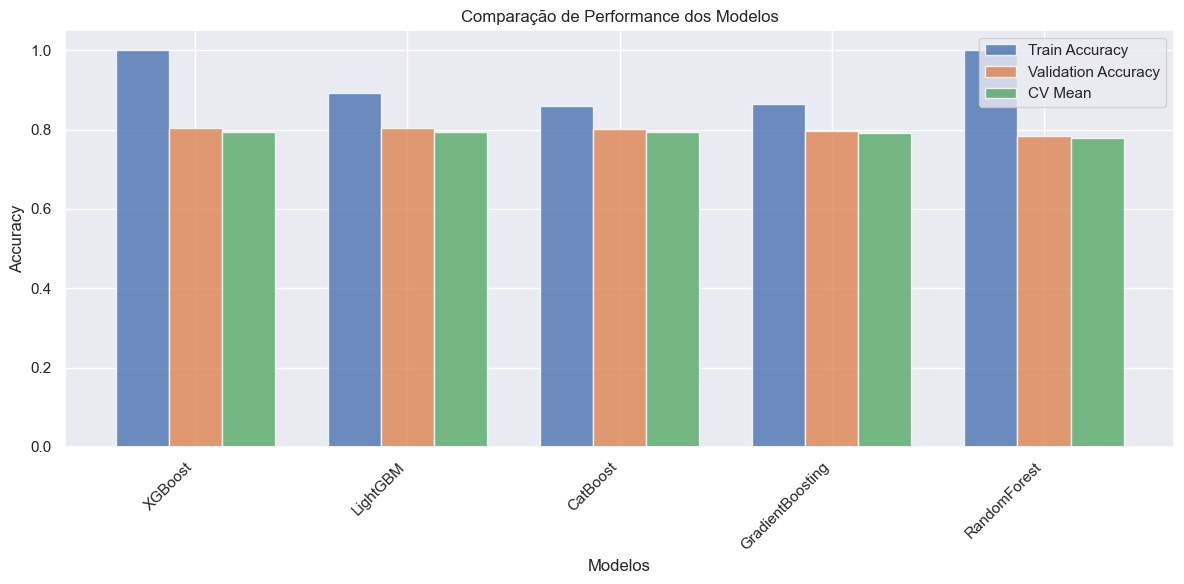

In [16]:
print("\n" + "="*60)
print("COMPARAÇÃO DE TODOS OS MODELOS")
print("="*60)

comparison_df = pd.DataFrame({
    'Modelo': list(results.keys()),
    'Train Acc': [results[m]['train_accuracy'] for m in results],
    'Val Acc': [results[m]['val_accuracy'] for m in results],
    'CV Mean': [results[m]['cv_mean'] for m in results],
    'CV Std': [results[m]['cv_std'] for m in results]
})

comparison_df = comparison_df.sort_values('Val Acc', ascending=False)
print("\n", comparison_df.to_string(index=False))

# Visualização
plt.figure(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.25

plt.bar(x - width, comparison_df['Train Acc'], width, label='Train Accuracy', alpha=0.8)
plt.bar(x, comparison_df['Val Acc'], width, label='Validation Accuracy', alpha=0.8)
plt.bar(x + width, comparison_df['CV Mean'], width, label='CV Mean', alpha=0.8)

plt.xlabel('Modelos')
plt.ylabel('Accuracy')
plt.title('Comparação de Performance dos Modelos')
plt.xticks(x, comparison_df['Modelo'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
print("\n" + "="*60)
print("A CRIAR VOTING CLASSIFIER (SOFT VOTING)")
print("="*60)

# Pegar os 3 melhores modelos
top_3_models = comparison_df.head(3)['Modelo'].tolist()
print(f"\nTop 3 modelos selecionados: {top_3_models}")

# Criar lista de estimadores para o Voting
voting_estimators = []
for model_name in top_3_models:
    model = results[model_name]['best_model']
    voting_estimators.append((model_name, model))

# Criar Voting Classifier com soft voting
voting_clf = VotingClassifier(
    estimators=voting_estimators,
    voting='soft',  # Soft voting = média das probabilidades
    n_jobs=-1
)

print("\nA Treinar Voting Classifier...")
# Treinar o voting classifier
voting_clf.fit(X_train, y_train)


# Avaliar
train_pred_voting = voting_clf.predict(X_train)
val_pred_voting = voting_clf.predict(X_val)

train_acc_voting = accuracy_score(y_train, train_pred_voting)
val_acc_voting = accuracy_score(y_val, val_pred_voting)

# Cross-validation
cv_scores_voting = cross_val_score(voting_clf, X_train, y_train, cv=5, scoring='accuracy')


print(f"Accuracy Treino: {train_acc_voting:.4f}")
print(f"Accuracy Validação: {val_acc_voting:.4f}")
print(f"CV Score: {cv_scores_voting.mean():.4f} (+/- {cv_scores_voting.std():.4f})")

# Adicionar aos resultados
results['VotingClassifier'] = {
    'best_params': f'Top 3: {top_3_models}',
    'train_accuracy': train_acc_voting,
    'val_accuracy': val_acc_voting,
    'cv_mean': cv_scores_voting.mean(),
    'cv_std': cv_scores_voting.std(),
    'best_model': voting_clf,
}

# Atualizar comparação
comparison_df = pd.DataFrame({
    'Modelo': list(results.keys()),
    'Train Acc': [results[m]['train_accuracy'] for m in results],
    'Val Acc': [results[m]['val_accuracy'] for m in results],
    'CV Mean': [results[m]['cv_mean'] for m in results],
    'CV Std': [results[m]['cv_std'] for m in results],
})

comparison_df = comparison_df.sort_values('Val Acc', ascending=False)

print("\n" + "="*60)
print(" COMPARAÇÃO FINAL (COM VOTING CLASSIFIER)")
print("="*60)
print("\n", comparison_df.to_string(index=False))



🗳️  CRIANDO VOTING CLASSIFIER (SOFT VOTING)

Top 3 modelos selecionados: ['XGBoost', 'LightGBM', 'CatBoost']

⏱️  Treinando Voting Classifier...
Accuracy Treino: 0.9742
Accuracy Validação: 0.8121
CV Score: 0.7987 (+/- 0.0149)

📊 COMPARAÇÃO FINAL (COM VOTING CLASSIFIER)

           Modelo  Train Acc  Val Acc  CV Mean   CV Std
VotingClassifier   0.974203 0.812133 0.798658 0.014859
         XGBoost   1.000000 0.804305 0.794256 0.017051
        LightGBM   0.891988 0.804305 0.792576 0.013470
        CatBoost   0.859899 0.802348 0.793206 0.018116
GradientBoosting   0.864723 0.795499 0.790060 0.010950
    RandomForest   1.000000 0.782779 0.777687 0.010130


In [23]:
best_model_name = comparison_df.iloc[0]['Modelo']
best_model = results[best_model_name]['best_model']

print(f"\n{'='*60}")
print(f"MELHOR MODELO: {best_model_name}")
print(f"{'='*60}")

# Treinar com todos os dados
print("\nTreinando com dataset completo...")
best_model.fit(X_train_full, y_train_full)

# Previsões no test
test_predictions = best_model.predict(X_test)

# Mapear de volta para labels
reverse_mapper = {0: "None", 1: "Low", 2: "Medium", 3: "High", 4: "Very_High"}
test_predictions_mapped = pd.Series(test_predictions).map(reverse_mapper)



MELHOR MODELO: VotingClassifier

Treinando com dataset completo...


In [24]:
output = pd.DataFrame({
    'RowId': range(1, len(test_predictions_mapped) + 1),
    'Speed_Diff': test_predictions_mapped
})
output.to_csv(f'{best_model_name}_predictions.csv', index=False)
print(f"\nPrevisões salvas em '{best_model_name}_predictions.csv'")

# Salvar previsões de todos os modelos
for name, model_info in results.items():
    model = model_info['best_model']
    model.fit(X_train_full, y_train_full)
    preds = model.predict(X_test)
    preds = preds.ravel() if preds.ndim > 1 else preds
    preds_mapped = pd.Series(preds).map(reverse_mapper)
    
    output = pd.DataFrame({
        'RowId': range(1, len(preds_mapped) + 1),
        'Speed_Diff': preds_mapped
    })
    output.to_csv(f'{name}_predictions.csv', index=False)
    print(f"Previsões de {name} salvas")

# Salvar comparação de modelos
comparison_df.to_csv('models_comparison.csv', index=False)
print("\nComparação de modelos salva em 'models_comparison.csv'")

print("\n" + "="*60)
print("PROCESSO COMPLETO!")
print("="*60)


Previsões salvas em 'VotingClassifier_predictions.csv'
Previsões de XGBoost salvas
Previsões de CatBoost salvas
Previsões de LightGBM salvas
Previsões de RandomForest salvas
Previsões de GradientBoosting salvas
Previsões de VotingClassifier salvas

Comparação de modelos salva em 'models_comparison.csv'

PROCESSO COMPLETO!
